In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("clean_dataset.csv")
display(df.head(5))

,Delivery_person_Age,Delivery_person_Ratings,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min),Preparation_Time_Min,order_month,orderd_hour
0,36.0,4.2,2022-02-12,1900-01-01 21:55:00,1900-01-01 22:10:00,Fog,Jam,Good,Snack,motorcycle,3.0,No,Metropolitian,46,15.0,2,21
1,21.0,4.7,2022-02-13,1900-01-01 14:55:00,1900-01-01 15:05:00,Stormy,High,Average,Meal,motorcycle,1.0,No,Metropolitian,23,10.0,2,14
2,23.0,4.7,2022-03-04,1900-01-01 17:30:00,1900-01-01 17:40:00,Sandstorms,Medium,Average,Drinks,scooter,1.0,No,Metropolitian,21,10.0,3,17
3,34.0,4.3,2022-02-13,1900-01-01 09:20:00,1900-01-01 09:30:00,Sandstorms,Low,Poor,Buffet,motorcycle,0.0,No,Metropolitian,20,10.0,2,9
4,24.0,4.7,2022-02-14,1900-01-01 19:50:00,1900-01-01 20:05:00,Fog,Jam,Average,Snack,scooter,1.0,No,Metropolitian,41,15.0,2,19


In [4]:
df.describe()

,Delivery_person_Age,Delivery_person_Ratings,multiple_deliveries,Time_taken (min),Preparation_Time_Min,order_month,orderd_hour
count,43012.000000,43012.000000,43012.000000,43012.000000,43012.000000,43012.000000,43012.000000
mean,29.557635,4.635753,0.751279,26.368525,9.955245,2.980843,17.545127
std,5.749027,0.311203,0.568548,9.391388,4.085582,0.546382,4.507709
min,20.000000,2.500000,0.000000,10.000000,5.000000,2.000000,8.000000
25%,25.000000,4.500000,0.000000,19.000000,5.000000,3.000000,15.000000
50%,30.000000,4.700000,1.000000,26.000000,10.000000,3.000000,19.000000
75%,35.000000,4.900000,1.000000,32.000000,15.000000,3.000000,21.000000
max,39.000000,5.000000,3.000000,54.000000,15.000000,4.000000,23.000000


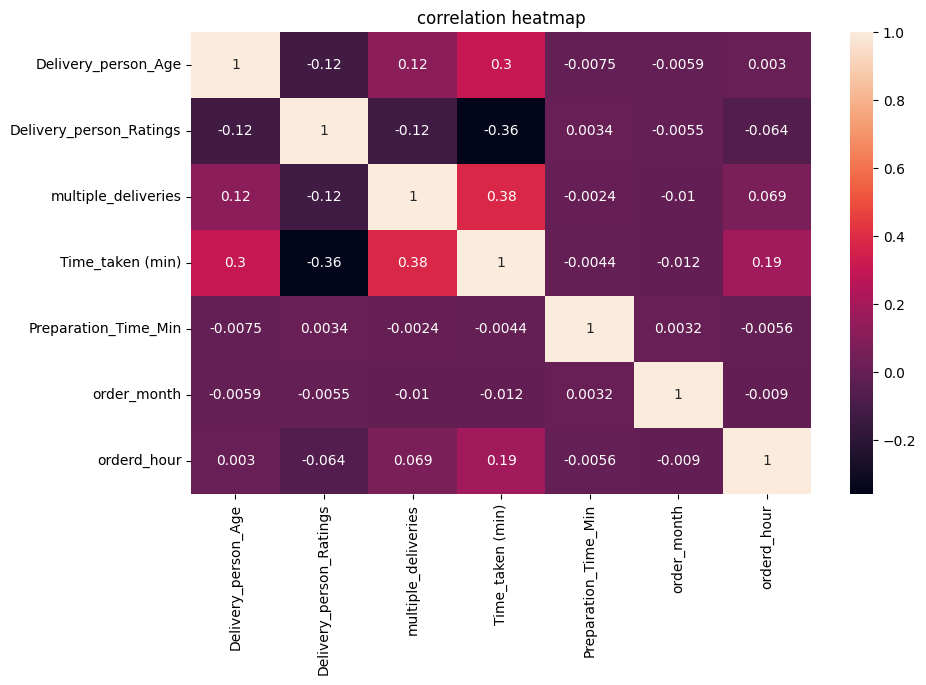

In [5]:
numeric_cols = df.select_dtypes(include=['float64' , 'int64'])
plt.figure(figsize=(10,6))
sns.heatmap(numeric_cols.corr() , annot=True  )
plt.title("correlation heatmap")
plt.show()

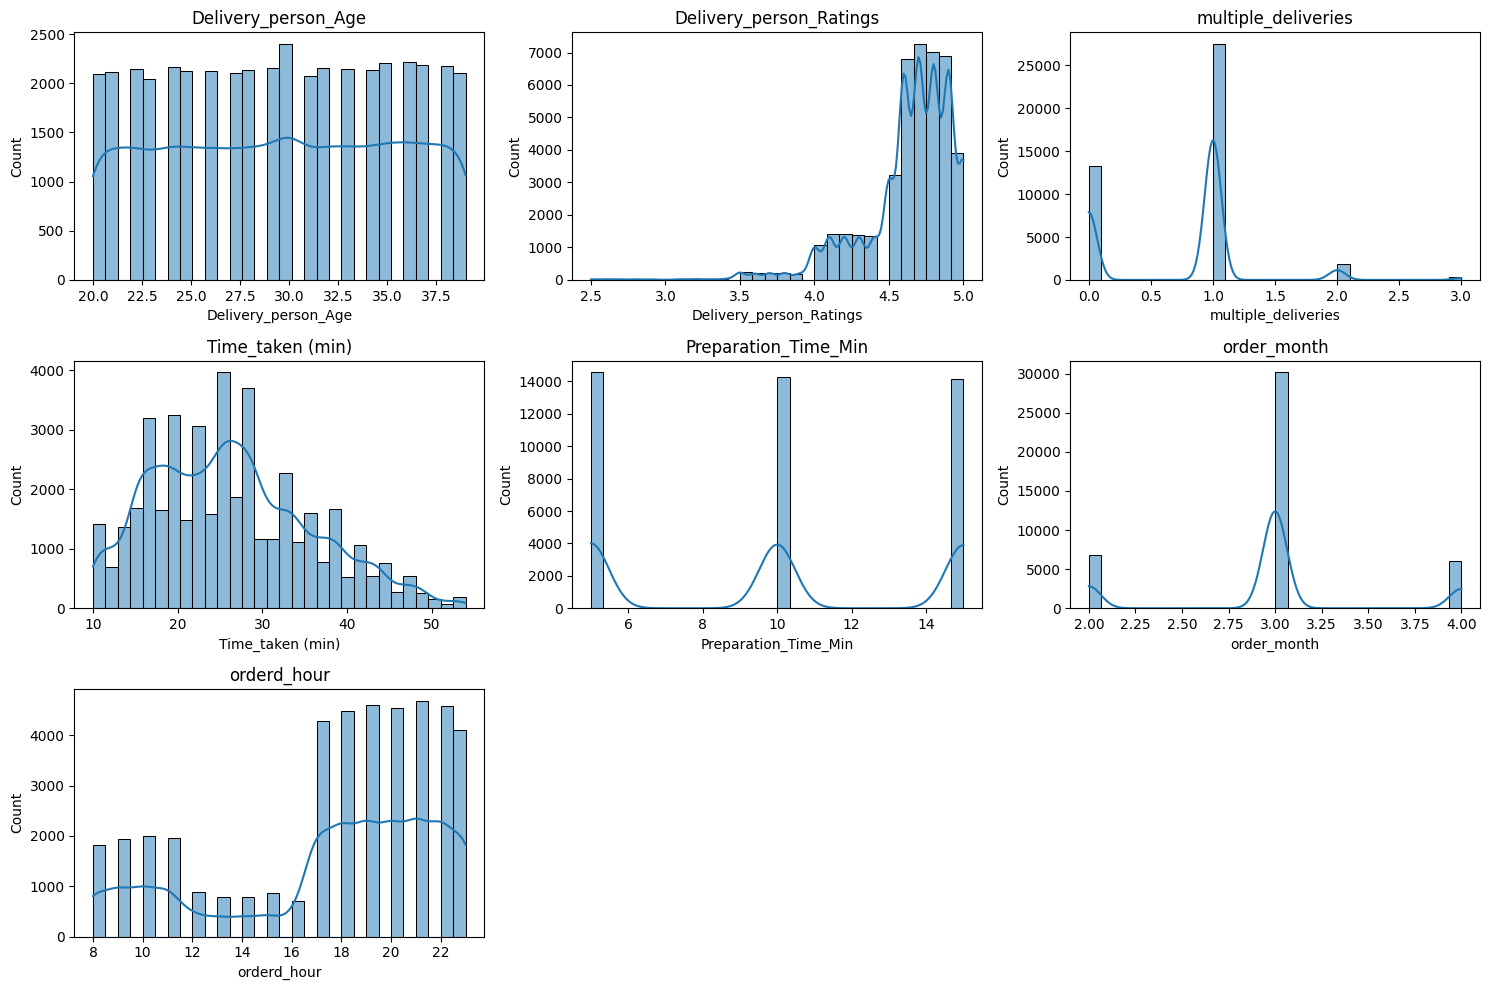

In [6]:
# numerical_cols = df.select_dtypes(include=["float64", "int64"]).columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(3, 3, i + 1) # adjust the number of rows and columns as needed
    sns.histplot(df[col], kde=True , bins = 30)
    plt.title(col)
plt.tight_layout()
plt.show()

In [8]:
df.columns

Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'Order_Date',
       'Time_Orderd', 'Time_Order_picked', 'Weather_conditions',
       'Road_traffic_density', 'Vehicle_condition', 'Type_of_order',
       'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City',
       'Time_taken (min)', 'Preparation_Time_Min', 'order_month',
       'orderd_hour'],
      dtype='object')

* KPI

In [9]:
avg_time_take = df['Time_taken (min)'].mean()
print(f"avg time taken : {avg_time_take.round(2)}")

avg_orderd_hour = df['orderd_hour'].mean()
print(f"avg orderd hour : {avg_orderd_hour.round(2)}")

avg_delivery_person_rating = df['Delivery_person_Ratings'].mean()
print(f"avg delivery person rate : {avg_delivery_person_rating.round(2)}")

avg_delivery_person_age = df['Delivery_person_Age'].mean()
print(f"delivery person's avg age : {avg_delivery_person_age.round(2)}")

avg_order_preparation_time = df['Preparation_Time_Min'].mean()
print(f"avg preparation time of orders : {avg_order_preparation_time.round(2)}")


avg time taken : 26.37
avg orderd hour : 17.55
avg delivery person rate : 4.64
delivery person's avg age : 29.56
avg preparation time of orders : 9.96


* age group wise delivery person distribution

,avg_time,avg_rating
age_group,,
20-24,23.06,4.68
25-29,23.05,4.68
30-34,29.60,4.59
35-39,29.59,4.60


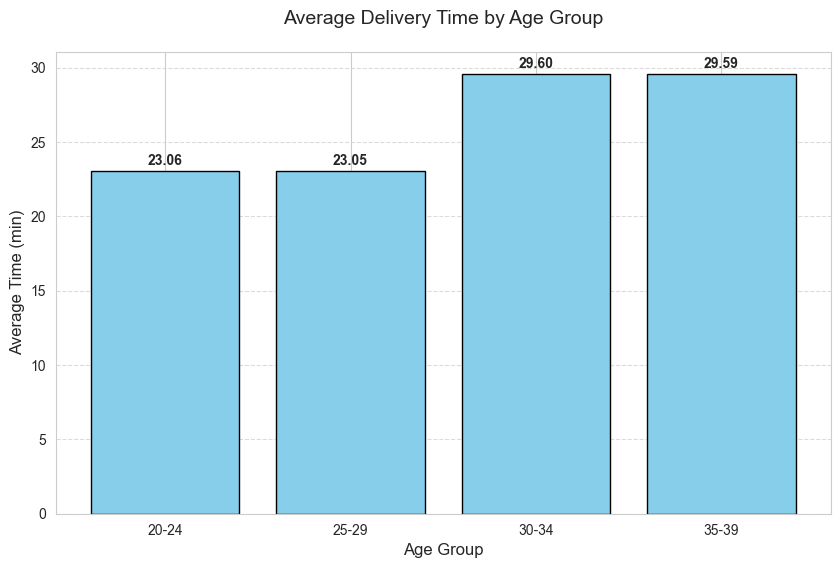

In [58]:
# Create age group column
bins = [19, 24, 29, 34, 39]

labels = [
    "20-24",
    "25-29",
    "30-34",
    "35-39"
]

df["age_group"] = pd.cut(
    df["Delivery_person_Age"],
    bins=bins,
    labels=labels
)

age_time = df.groupby('age_group').agg(
    avg_time=('Time_taken (min)', 'mean'),
    avg_rating=('Delivery_person_Ratings', 'mean')
).round(2)
display(age_time)
plt.figure(figsize=(10, 6))
bars = plt.bar(age_time.index, age_time['avg_time'], color='skyblue', edgecolor='black')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.2, f'{height:.2f}', ha='center', va='bottom', fontweight='bold')

plt.title('Average Delivery Time by Age Group', fontsize=14, pad=20)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Average Time (min)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Contrary to assumption, younger delivery partners (20-29) are faster (~23 min avg) and rated higher (4.68) than older partners (30-39), who average ~29.6 min and 4.59-4.60 rating. Experience does not translate to speed here — possibly due to route/vehicle assignment differences rather than skill.**

* base on vehical condition avg delivery person rate

,avg_delivery_person_rate
Vehicle_condition,
Average,4.65
Good,4.65
Poor,4.61


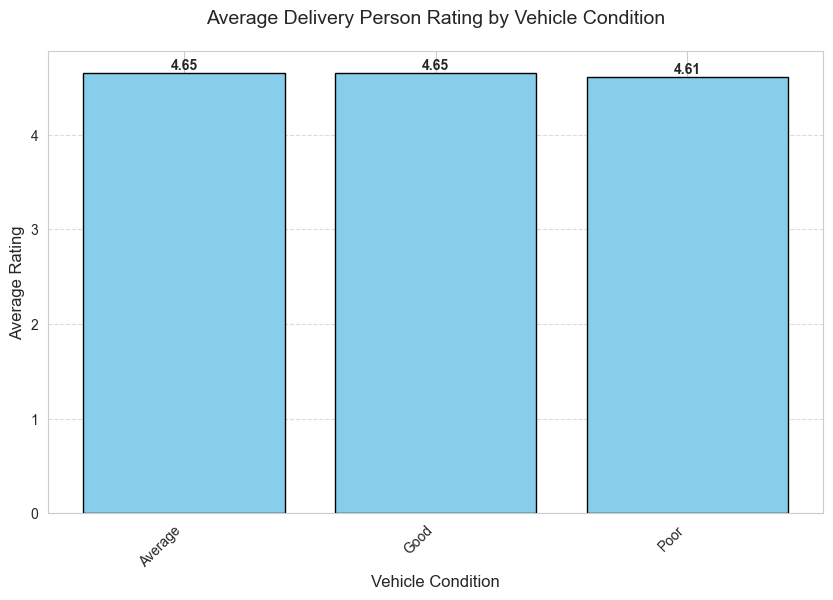

In [11]:
vehical_condition = df.groupby('Vehicle_condition').agg(
    avg_delivery_person_rate = ('Delivery_person_Ratings' , 'mean')
).round(2)

display(vehical_condition.sort_values(by='avg_delivery_person_rate' , ascending=False))

plt.figure(figsize=(10, 6))
bars = plt.bar(
    vehical_condition.index,
    vehical_condition['avg_delivery_person_rate'],
    color='skyblue',
    edgecolor='black'
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f'{height:.2f}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.title('Average Delivery Person Rating by Vehicle Condition', fontsize=14, pad=20)
plt.xlabel('Vehicle Condition', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

**Vehicle condition has minimal impact on delivery person ratings, as Average and Good conditions both yield an identical average rating of 4.65, while Poor conditions only slightly dip to 4.61.**

* base on vehical condition avg time taken for deliver order

,avg_time
Vehicle_condition,
Poor,30.16
Good,24.53
Average,24.43


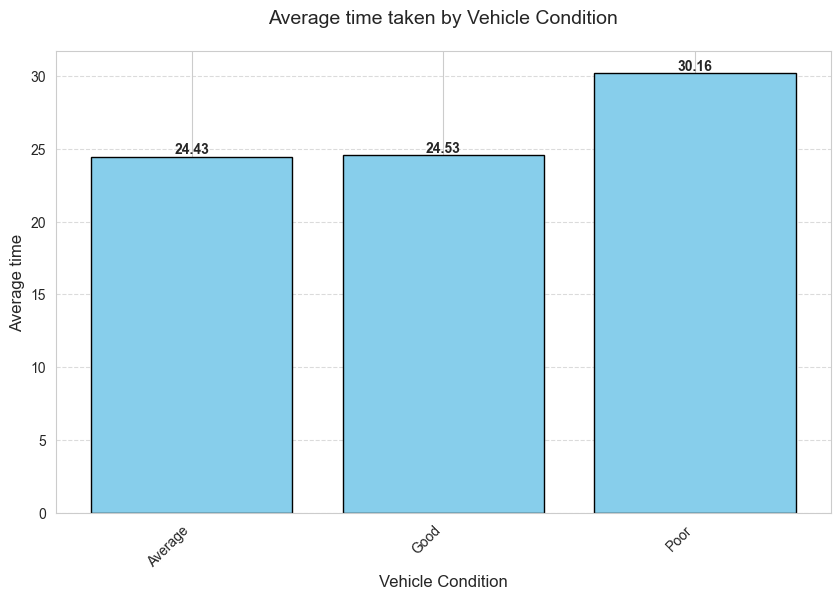

In [12]:
avg_time = df.groupby('Vehicle_condition').agg(
    avg_time = ('Time_taken (min)' , 'mean')
).round(2)

display(avg_time.sort_values(by="avg_time", ascending=False))

plt.figure(figsize=(10, 6))
bars = plt.bar(
    avg_time.index,
    avg_time['avg_time'],
    color='skyblue',
    edgecolor='black'
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f'{height:.2f}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.title('Average time taken by Vehicle Condition', fontsize=14, pad=20)
plt.xlabel('Vehicle Condition', fontsize=12)
plt.ylabel('Average time', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

**Delivery times are ~20% slower for vehicles in Poor condition (30.16 mins) compared to Good/Average (24.53–24.43 mins), highlighting maintenance as a critical factor for efficiency.**

* base on vehical type avg time taken

,avg_time
Type_of_vehicle,
motorcycle,27.69
scooter,24.52
electric_scooter,24.47


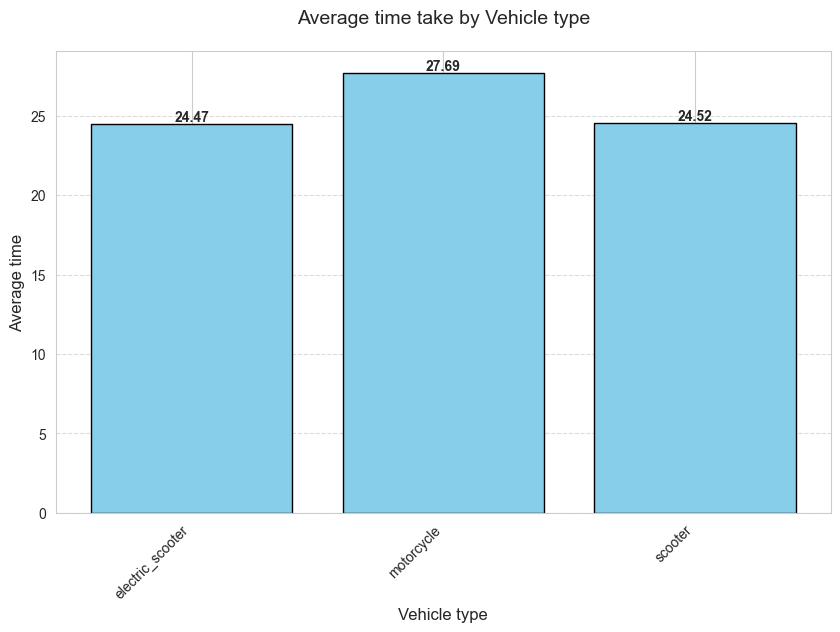

In [13]:
vehical_type = df.groupby('Type_of_vehicle').agg(
    avg_time = ('Time_taken (min)' , 'mean')
).round(2)
display(vehical_type.sort_values(by='avg_time' , ascending=False))

plt.figure(figsize=(10, 6))
bars = plt.bar(
    vehical_type.index,
    vehical_type['avg_time'],
    color='skyblue',
    edgecolor='black'
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f'{height:.2f}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.title('Average time take by Vehicle type', fontsize=14, pad=20)
plt.xlabel('Vehicle type', fontsize=12)
plt.ylabel('Average time', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

**Scooters and electric scooters deliver ~3 minutes faster on average than motorcycles, suggesting higher efficiency for shorter or urban deliveries.**

* type of order distribution

Type_of_order
Snack     10853
Meal      10809
Drinks    10701
Buffet    10649
Name: count, dtype: int64

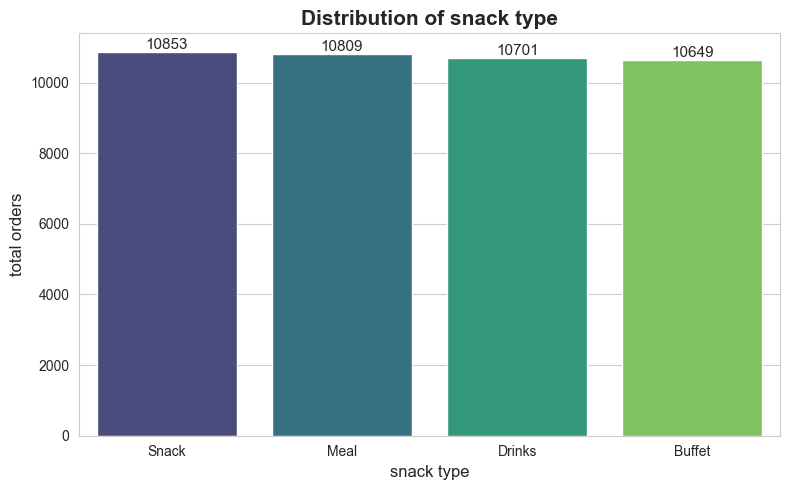

In [14]:
order_type = df['Type_of_order'].value_counts()
display(order_type.sort_values(ascending=False))

# Set plot style
sns.set_style("whitegrid")

# Create figure
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="Type_of_order",
    palette="viridis"
)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fontsize=11)

# Customize plot
plt.title("Distribution of snack type", fontsize=15, fontweight="bold")
plt.xlabel("snack type", fontsize=12)
plt.ylabel("total orders", fontsize=12)

plt.tight_layout()
plt.show()

**Order types are almost evenly distributed, with Snacks and Meals leading marginally, suggesting consistent demand across all categories.**

* road trafiic density wise avg time taken

,avg_time
Road_traffic_density,
Jam,31.15
High,27.21
Medium,26.72
Low,21.21


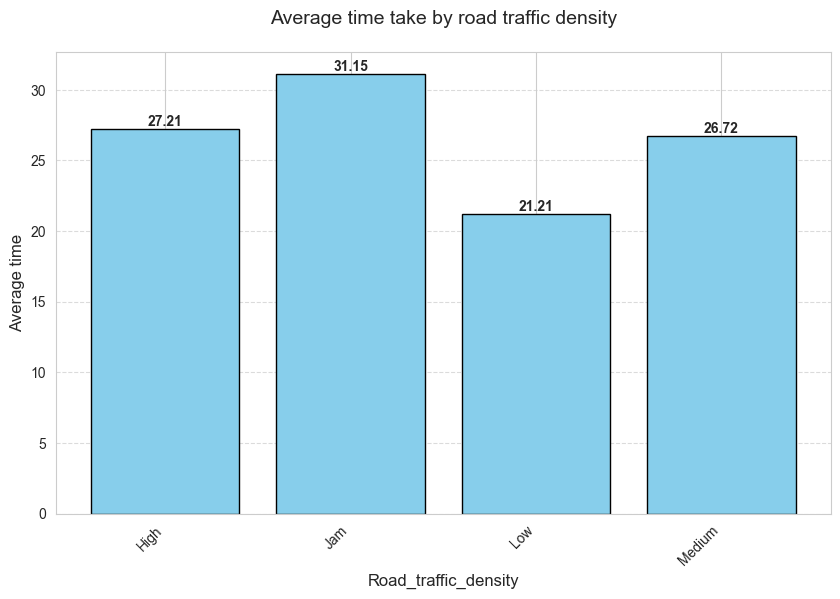

In [15]:
traffic = df.groupby('Road_traffic_density').agg(
    avg_time = ('Time_taken (min)' , 'mean')
).round(2)

display(traffic.sort_values(by='avg_time' , ascending=False))
plt.figure(figsize=(10, 6))
bars = plt.bar(
    traffic.index,
    traffic['avg_time'],
    color='skyblue',
    edgecolor='black'
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f'{height:.2f}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.title('Average time take by road traffic density', fontsize=14, pad=20)
plt.xlabel('Road_traffic_density', fontsize=12)
plt.ylabel('Average time', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


**Higher road traffic density (Jam/High) correlates with ~25-30% longer delivery times compared to Low/Medium traffic, highlighting traffic as a critical bottleneck in delivery efficiency.**

* is it possible when driver have multiple deliveries at same time then avg time(for deliver order) taken is higher??

,avg_time
multiple_deliveries,
3.0,47.82
2.0,40.43
1.0,26.80
0.0,22.92


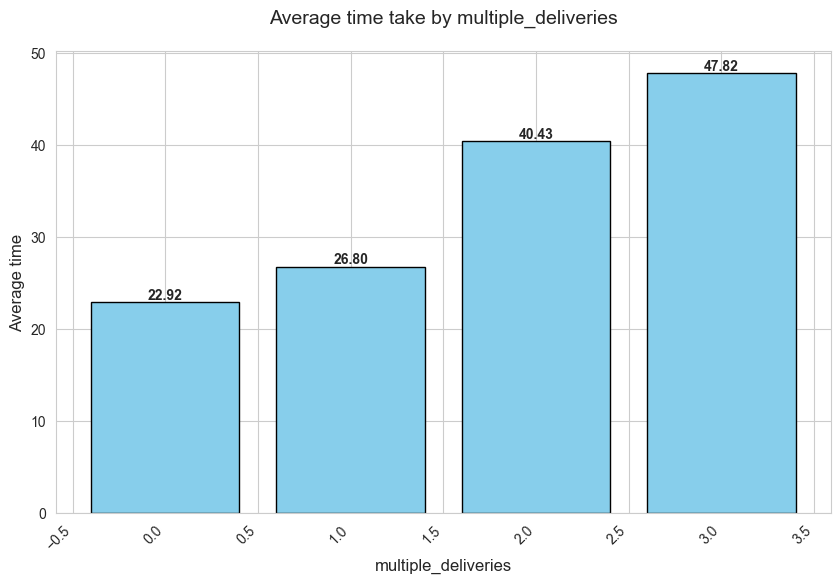

In [ ]:
multiple_delivery = df.groupby('multiple_deliveries').agg(
    avg_time = ('Time_taken (min)' , 'mean')
).round(2)
display(multiple_delivery.sort_values(by='avg_time',ascending=False))

plt.figure(figsize=(10, 6))
bars = plt.bar(
    multiple_delivery.index,
    multiple_delivery['avg_time'],
    color='skyblue',
    edgecolor='black'
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f'{height:.2f}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.title('Average time take by multiple_deliveries', fontsize=14, pad=20)
plt.xlabel('multiple_deliveries', fontsize=12)
plt.ylabel('Average time', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.show()

**Orders assigned with higher multiple-delivery counts show a clear increase in average delivery time, rising from 22.92 minutes with no multiple delivery to 47.82 minutes at three deliveries.**

**This suggests that delivery stacking significantly affects fulfillment speed and should be managed to avoid service delays.**

* hourly distribution of orders

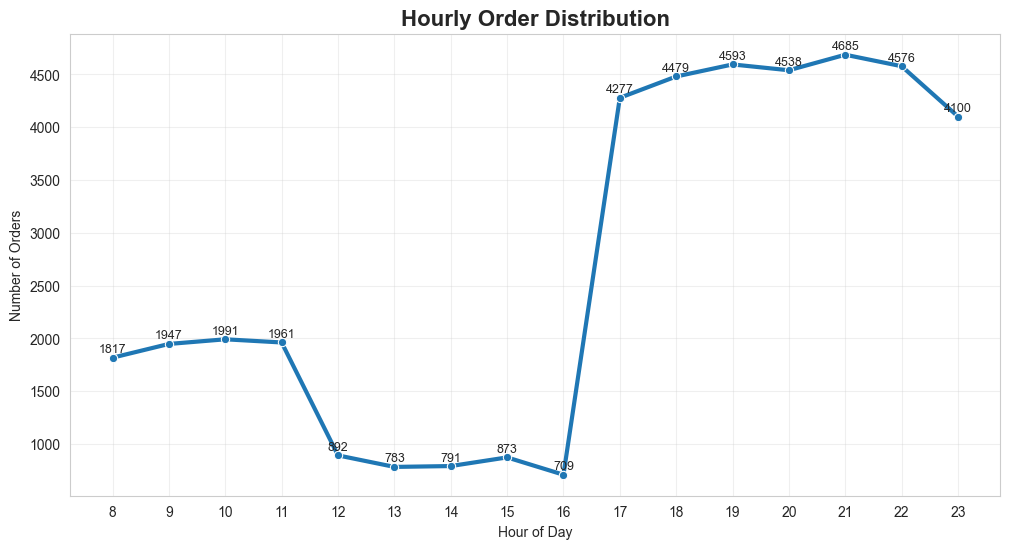

In [47]:
hourly_distribution = df['orderd_hour'].value_counts(ascending=True)
# display(hourly_distribution)
plt.figure(figsize=(12,6))

sns.lineplot(
    x=hourly_distribution.index,
    y=hourly_distribution.values,
    marker='o',
    linewidth=3
)


# Add value labels
for x, y in zip(hourly_distribution.index, hourly_distribution.values):
    plt.text(x, y + 50, str(y), ha='center', fontsize=9)
plt.title("Hourly Order Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")
plt.xticks(hourly_distribution.index)
plt.grid(alpha=0.3)

plt.show()

**Order activity is highest during the evening hours, with the strongest concentration between 19:00 and 23:00, reflecting dinner-time ordering behavior.**

* monthly distribution

In [59]:
day_coverage = df.groupby('order_month')['Order_Date'].nunique()
print("Unique days of data per month:")
print(day_coverage)

Unique days of data per month:
order_month
2     8
3    30
4     6
Name: Order_Date, dtype: int64


**March appears highest in raw order count (30,156) but the dataset only contains 8 days of February and 6 days of April vs a full 30 days of March. This is a data coverage artifact, not a real demand surge — monthly comparison isn't valid on this dataset without normalizing by day count.**

* city wise zomato used distribution

,City,Total_Orders
0,Metropolitian,33313
2,Urban,9543
1,Semi-Urban,156


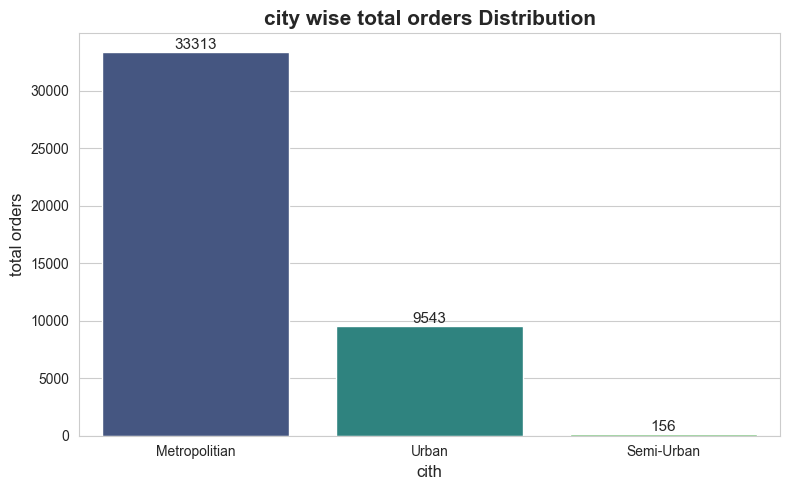

In [61]:
city_orders = (
    df.groupby("City")
      .size()
      .reset_index(name="Total_Orders")
)

display(city_orders.sort_values(by='Total_Orders' , ascending=False))
# Set plot style
sns.set_style("whitegrid")

# Create figure
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="City",
    palette="viridis"
)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fontsize=11)

# Customize plot
plt.title("city wise total orders Distribution", fontsize=15, fontweight="bold")
plt.xlabel("cith", fontsize=12)
plt.ylabel("total orders", fontsize=12)

plt.tight_layout()
plt.show()


**Zomato order volume is overwhelmingly concentrated in metropolitan cities, with urban areas contributing a moderate share and semi-urban regions showing minimal usage. This reflects the platform’s strong dependence on high-demand urban markets.**

* City wise avg delivery time

,avg_time
City,
Semi-Urban,49.74
Metropolitian,27.21
Urban,23.06


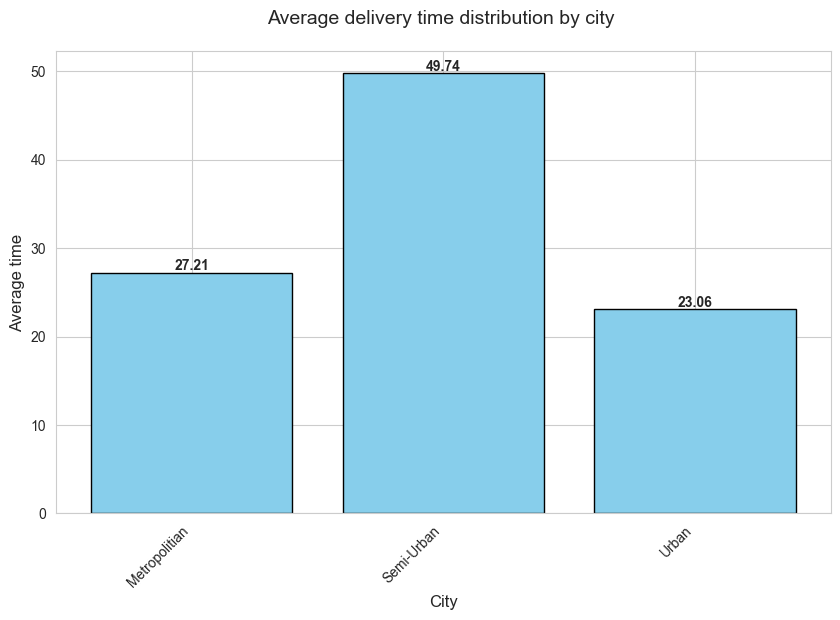

In [57]:
city_time = df.groupby('City').agg(
    avg_time = ('Time_taken (min)' , 'mean')
).round(2)
display(city_time.sort_values(by='avg_time' , ascending=False))

plt.figure(figsize=(10, 6))
bars = plt.bar(
    city_time.index,
    city_time['avg_time'],
    color='skyblue',
    edgecolor='black'
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f'{height:.2f}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.title('Average delivery time distribution by city ', fontsize=14, pad=20)
plt.xlabel('City', fontsize=12)
plt.ylabel('Average time', fontsize=12)
plt.xticks(rotation=45, ha='right')
# plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


**Semi-Urban deliveries take nearly double the time (49.74 min) compared to Metropolitan (27.21 min) and Urban (23.06 min), despite having the fewest orders (156). This points to limited rider coverage or infrastructure gaps in semi-urban areas rather than a demand issue.**

* order distribution by wether condition

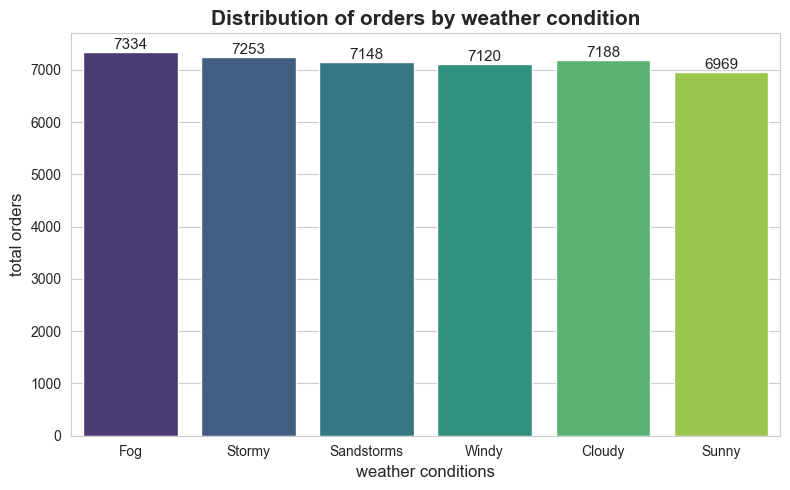

In [ ]:
weather_orders = (
    df["Weather_conditions"]
    .value_counts()
    .sort_values(ascending=False)
)
# display(weather_orders)
sns.set_style("whitegrid")

# Create figure
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="Weather_conditions",
    palette="viridis"
)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fontsize=11)

# Customize plot
plt.title("Distribution of orders by weather conditions", fontsize=15, fontweight="bold")
plt.xlabel("weather conditions", fontsize=12)
plt.ylabel("total orders", fontsize=12)

plt.tight_layout()
plt.show()


**Fog records the highest order volume, closely followed by Stormy and Cloudy conditions, while Sunny weather shows the lowest count.This suggests that customer ordering behavior remains relatively stable across different weather types, and demand does not drop sharply during unfavorable conditions.**

* whether condition wise avg delivery time

,avg_delivery_time
Weather_conditions,
Cloudy,29.04
Fog,28.98
Windy,26.21
Sandstorms,26.00
Stormy,25.98
Sunny,21.81


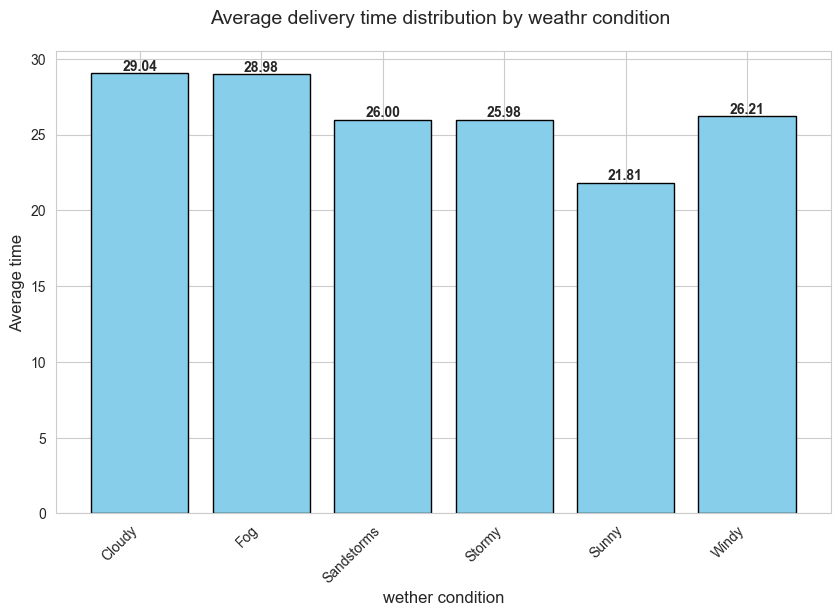

In [63]:
weather_avg_delivery = df.groupby('Weather_conditions').agg(
    avg_delivery_time = ('Time_taken (min)' , 'mean')
).round(2)
display(weather_avg_delivery.sort_values(by='avg_delivery_time' , ascending=False))

plt.figure(figsize=(10, 6))
bars = plt.bar(
    weather_avg_delivery.index,
    weather_avg_delivery['avg_delivery_time'],
    color='skyblue',
    edgecolor='black'
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f'{height:.2f}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.title('Average delivery time distribution by weathr condition ', fontsize=14, pad=20)
plt.xlabel('wether condition', fontsize=12)
plt.ylabel('Average time', fontsize=12)
plt.xticks(rotation=45, ha='right')
# plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

**Delivery time is highest in cloudy and foggy conditions, while sunny weather enables the fastest deliveries. This shows that weather conditions have a clear operational impact on delivery efficiency and should be considered in delivery-time forecasting and rider allocation.**

* Vehicle Usage in Different Weather

Type_of_vehicle,electric_scooter,motorcycle,scooter
Weather_conditions,,,
Cloudy,572,4167,2449
Fog,620,4270,2444
Sandstorms,557,4182,2409
Stormy,582,4240,2431
Sunny,560,4085,2324
Windy,570,4206,2344


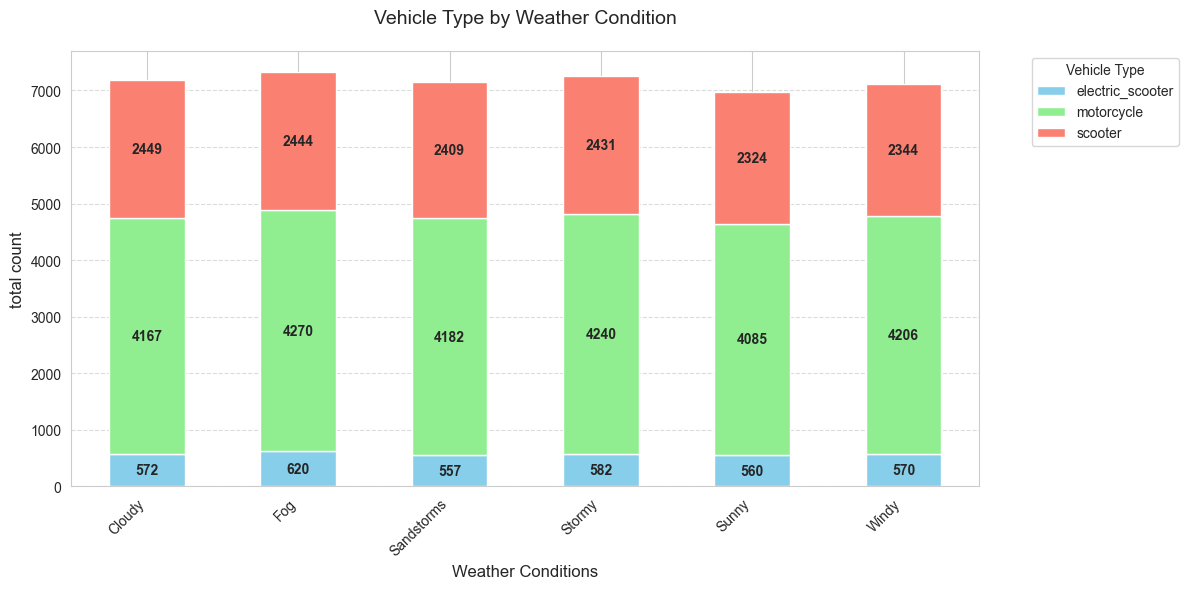

In [39]:
vehicle_weather = pd.crosstab(
    df["Weather_conditions"],
    df["Type_of_vehicle"]
)

display(vehicle_weather)

# Plotting
ax = vehicle_weather.plot(
    kind="bar",
    figsize=(12, 6),
    stacked=True,
    color=['skyblue', 'lightgreen', 'salmon', 'gold']
)

# Add data labels
for container in ax.containers:
    ax.bar_label(container, label_type='center', fmt='%.0f', padding=0, fontweight='bold')

# Customize the plot
plt.title("Vehicle Type by Weather Condition", fontsize=14, pad=20)
plt.xlabel("Weather Conditions", fontsize=12)
plt.ylabel("total count", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Vehicle Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.show()

**Motorcycle usage is the most dominant across all weather conditions, while scooter usage stays consistently strong and electric scooters remain lower in comparison. The pattern indicates that delivery operations are not heavily altered by weather, but instead continue to depend on traditional two-wheel vehicles for reliability and coverage.**

* orders distribution on festival season

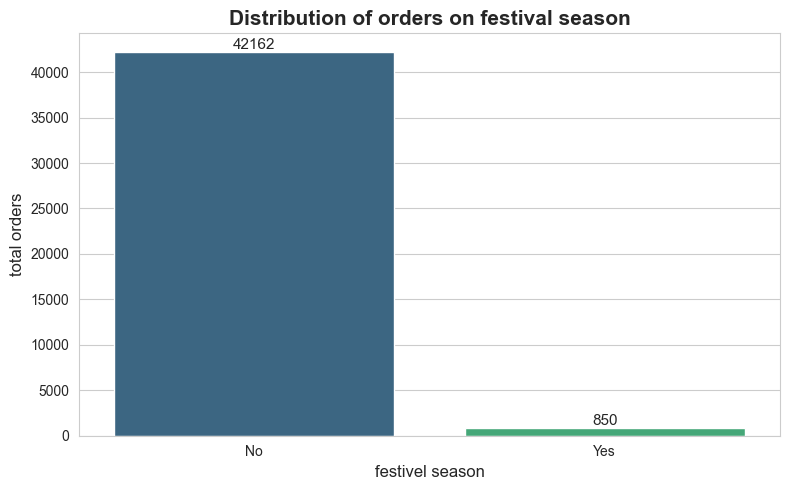

In [64]:
festival_season = df.groupby('Festival').size()
# display(festival_season.sort_values(ascending=False))

# Set plot style
sns.set_style("whitegrid")

# Create figure
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="Festival",
    palette="viridis"
)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fontsize=11)

# Customize plot
plt.title("Distribution of orders on festival season", fontsize=15, fontweight="bold")
plt.xlabel("festivel season", fontsize=12)
plt.ylabel("total orders", fontsize=12)

plt.tight_layout()
plt.show()

**Festival season orders are overwhelmingly driven by non-festival days.**

**The distribution shows a very strong imbalance, with 42,162 orders on “No” festival days compared with only 850 orders during festivals. This indicates that the platform’s core demand is concentrated in normal operating periods rather than seasonal spikes.**

* avg delivery time on festival season

,avg_time
Festival,
No,25.98
Yes,45.53


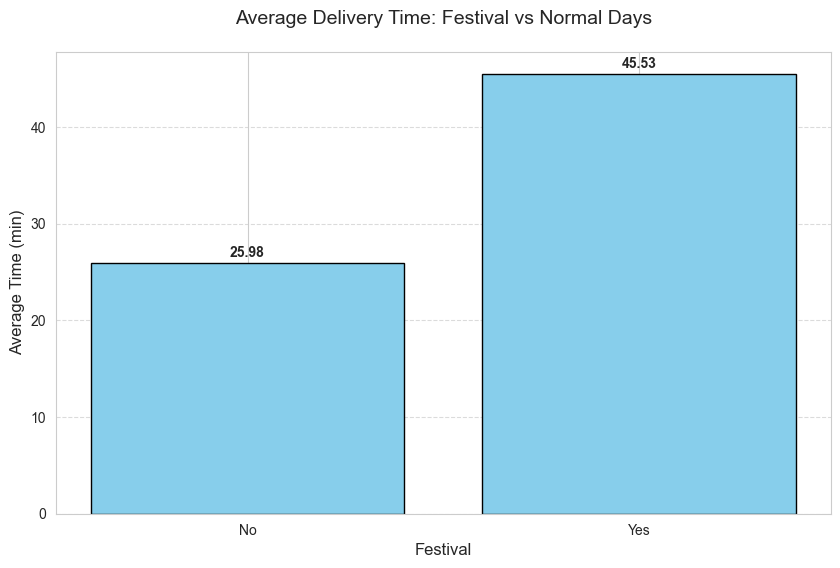

In [60]:
festival_time = df.groupby('Festival').agg(
    avg_time=('Time_taken (min)', 'mean')
).round(2)

display(festival_time)

plt.figure(figsize=(10, 6))
bars = plt.bar(festival_time.index, festival_time['avg_time'], color='skyblue', edgecolor='black')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.3, f'{height:.2f}', ha='center', va='bottom', fontweight='bold')

plt.title('Average Delivery Time: Festival vs Normal Days', fontsize=14, pad=20)
plt.xlabel('Festival', fontsize=12)
plt.ylabel('Average Time (min)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Delivery time jumps ~75% during festivals (45.53 min vs 25.98 min on normal days), even though festival orders are only ~2% of total volume. Festivals don't drive volume but severely strain fulfillment speed — a case for temporary surge staffing or rider incentives during these periods.**